In [19]:
import optuna
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
study = optuna.load_study(
    storage=r"sqlite:///4mmccw.sqlite3",
    study_name="resnet_50_128img_XYZV150_all_2Z",
)

In [21]:
df = study.trials_dataframe()
df = df[df.state == "COMPLETE"]
df.describe()

,number,value,datetime_start,datetime_complete,duration,params_width,params_x,params_y,params_z,user_attrs_attempts,user_attrs_failed
count,688.000000,688.000000,688,688,688,688.000000,688.000000,688.000000,688.000000,688.000000,688.000000
mean,344.784884,0.768622,2026-04-23 16:58:51.538701,2026-04-23 16:59:11.682616,0 days 00:00:20.143914,1.405523,122.474128,153.056977,0.719549,2.286337,0.360465
min,0.000000,0.676719,2026-04-23 14:10:12.518950,2026-04-23 14:10:25.166309,0 days 00:00:10.044266,1.000000,118.000000,148.000000,0.000000,2.000000,0.000000
25%,171.750000,0.757812,2026-04-23 15:04:12.396517,2026-04-23 15:04:35.356427,0 days 00:00:11.897857,1.000000,120.700000,151.600000,0.340000,2.000000,0.000000
50%,344.500000,0.757812,2026-04-23 17:46:44.188398,2026-04-23 17:46:59.033944,0 days 00:00:12.341099,1.000000,122.350000,153.150000,0.630000,2.000000,0.000000
75%,518.250000,0.780469,2026-04-23 18:52:10.482022,2026-04-23 18:52:33.199425,0 days 00:00:19.257247,2.000000,124.225000,154.500000,0.980000,2.000000,1.000000
max,691.000000,0.833594,2026-04-23 19:49:31.924723,2026-04-23 19:49:44.052573,0 days 00:01:30.522960,2.000000,127.000000,158.000000,2.000000,6.000000,3.000000
std,200.128875,0.021499,NaN,NaN,0 days 00:00:14.474203,0.491350,2.340604,2.159757,0.488568,0.606361,0.601556


In [22]:
df = df.explode("user_attrs_top-1")

df = df.reset_index(drop=True)

In [23]:
df = df[["params_x", "params_y", "params_z", "user_attrs_top-1"]]
df.to_csv("data.csv", index=False)

In [24]:
df_unchanged = df[df["user_attrs_top-1"] == 0.7578125]
df_failed = df[df["user_attrs_top-1"] == -1]
df_one = df[(df["user_attrs_top-1"] != 0.7578125) & (df["user_attrs_top-1"] != -1)]
df_success = df[(df["user_attrs_top-1"] < 0.5) & (df["user_attrs_top-1"] != -1)]

In [25]:
df.head()

,params_x,params_y,params_z,user_attrs_top-1
0,122.3,156.4,1.52,0.757812
1,122.3,156.4,1.52,0.757812
2,124.3,149.5,0.45,-1.0
3,124.3,149.5,0.45,0.757812
4,123.8,154.4,0.24,0.75


In [26]:
df_one.mode()

,params_x,params_y,params_z,user_attrs_top-1
0,121.5,152.9,0.35,0.75
1,121.6,NaN,NaN,NaN


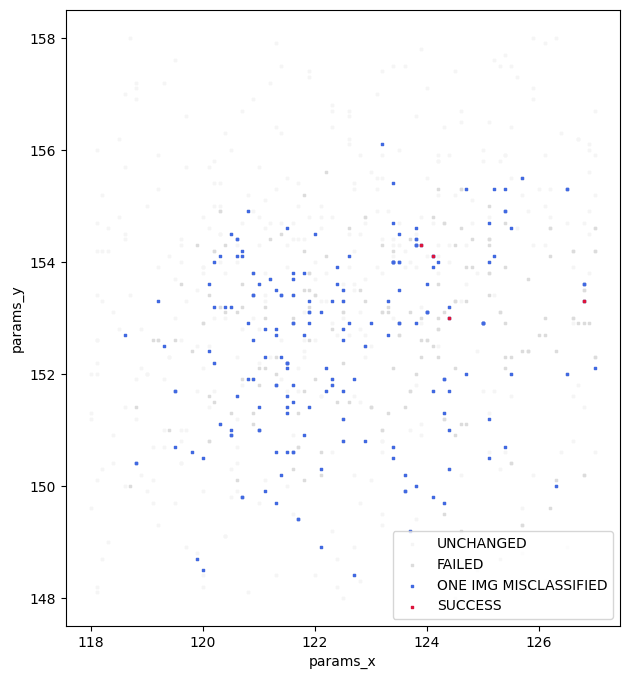

In [27]:
SCALE = 8
MARKER = 1

fig, ax = plt.subplots(figsize=(SCALE, SCALE))

ax.set_aspect("equal")

param_x = "params_x"
param_y = "params_y"

ax.scatter(
    df_unchanged[param_x],
    df_unchanged[param_y],
    c="whitesmoke",
    label="UNCHANGED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_failed[param_x],
    df_failed[param_y],
    c="gainsboro",
    label="FAILED",
    s=MARKER,
    marker="s",
)
ax.scatter(
    df_one[param_x],
    df_one[param_y],
    c="royalblue",
    label="ONE IMG MISCLASSIFIED",
    s=MARKER,
    marker="s",
)

ax.scatter(
    df_success[param_x],
    df_success[param_y],
    c="crimson",
    label="SUCCESS",
    s=MARKER,
    marker="s",
)

ax.set_xlabel(param_x)
ax.set_ylabel(param_y)
ax.legend()

plt.savefig("2d.svg")